# Análisis Exploratorio de Datos — Precios de Propiedades en CABA

Con el dataset ya limpio y procesado, realizamos un análisis exploratorio
para entender la distribución de las variables, identificar patrones y 
relaciones entre ellas. Este análisis nos permitirá tomar decisiones 
informadas sobre qué features usar en un modelo en el futuro.

## Variables disponibles
- `precio`: precio de venta en USD
- `expensas`: expensas mensuales en ARS
- `metros`: superficie total en m²
- `ambientes`: cantidad de ambientes
- `banos`: cantidad de baños
- `barrio`: barrio oficial según GCBA
- `comuna`: comuna a la que pertenece el barrio

## Estructura del análisis
1. Carga y vista general del dataset
2. Distribución de cada variable
3. Relaciones entre variables
4. Análisis por barrio y comuna

### 1. Imports/Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

### 2. Carga

In [3]:
df = pd.read_csv("../data/processed/zonaprop_clean.csv")

print(f"Filas: {len(df):,}")
print(f"Columnas: {df.columns.tolist()}")
df.head()

Filas: 32,946
Columnas: ['precio', 'expensas', 'metros', 'ambientes', 'banos', 'barrio', 'comuna']


,precio,expensas,metros,ambientes,banos,barrio,comuna
0,"530,000.00",770000,172.00,4.00,3.00,PALERMO,14
1,"170,000.00",0,73.00,4.00,1.00,VILLA CRESPO,15
2,"120,000.00",260000,54.00,3.00,1.00,RECOLETA,2
3,"220,000.00",380073,68.00,3.00,2.00,NUÑEZ,13
4,"84,100.00",110000,55.00,1.00,1.00,VILLA LURO,10


### 3. Vista general

In [4]:
df.describe()

,precio,expensas,metros,ambientes,banos,comuna
count,"32,946.00","32,946.00","32,946.00","32,946.00","32,946.00","32,946.00"
mean,"275,377.41","194,138.14",103.85,2.95,1.58,8.79
std,"256,847.79","266,719.43",80.11,1.44,0.81,5.06
min,"54,900.00",0.00,25.00,1.00,1.00,1.00
25%,"123,000.00",0.00,49.00,2.00,1.00,3.00
50%,"187,000.00","113,000.00",77.00,3.00,1.00,11.00
75%,"320,000.00","270,000.00",128.00,4.00,2.00,13.00
max,"2,500,000.00","1,500,000.00",500.00,10.00,6.00,15.00


### 2. Distribución de variables numéricas

#### 2.1 Precio

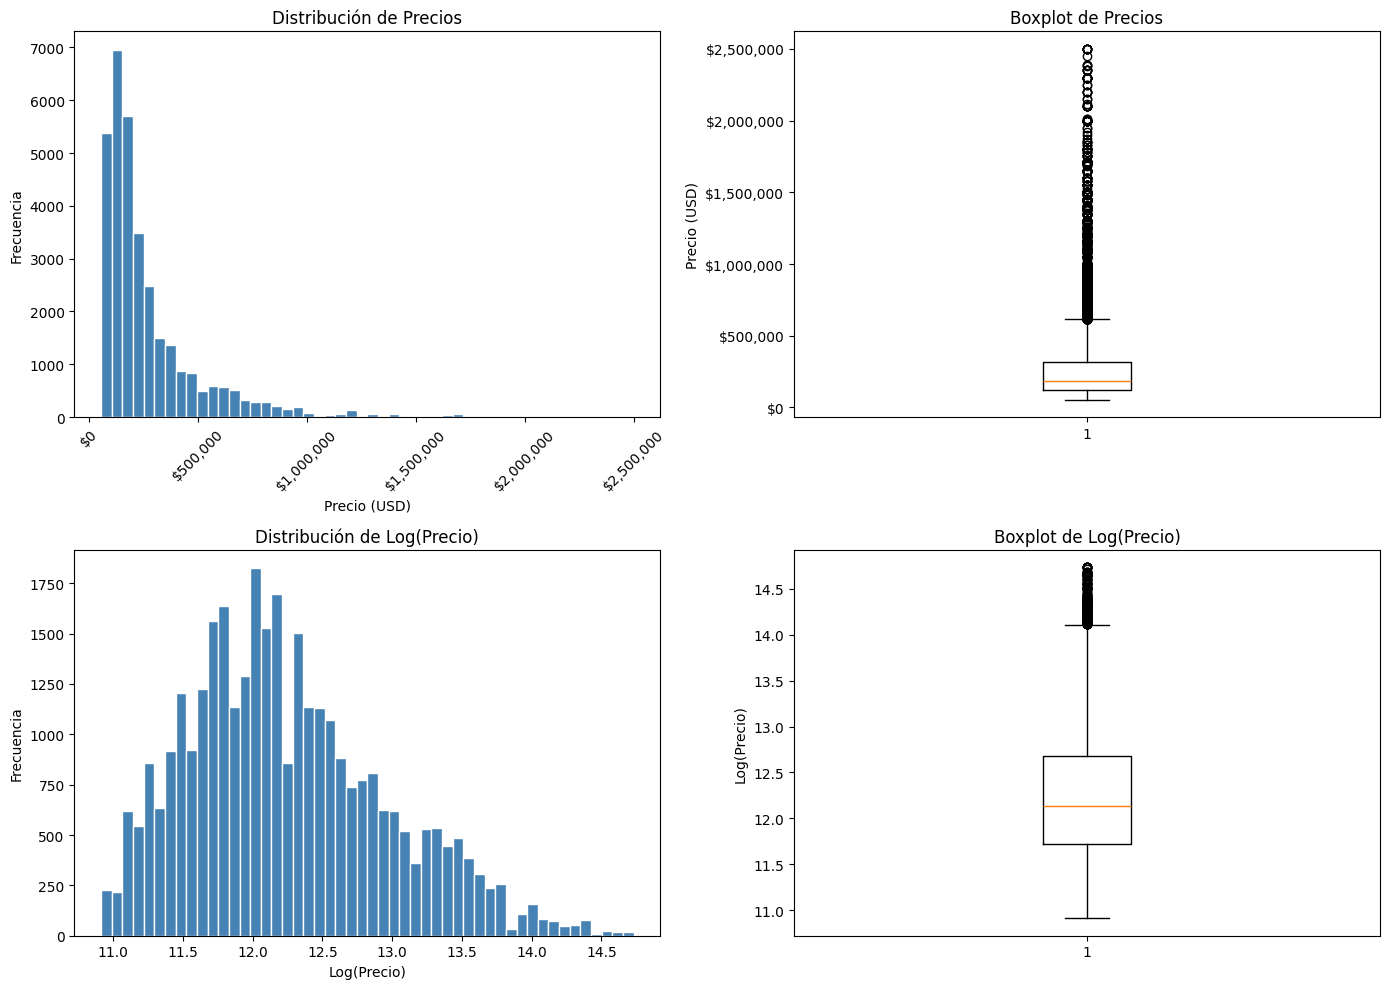

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma precio original
axes[0, 0].hist(df["precio"], bins=50, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Distribución de Precios")
axes[0, 0].set_xlabel("Precio (USD)")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45)

# Boxplot precio original
axes[0, 1].boxplot(df["precio"], vert=True)
axes[0, 1].set_title("Boxplot de Precios")
axes[0, 1].set_ylabel("Precio (USD)")
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

# Histograma log precio
log_precio = np.log(df["precio"])
axes[1, 0].hist(log_precio, bins=50, color="steelblue", edgecolor="white")
axes[1, 0].set_title("Distribución de Log(Precio)")
axes[1, 0].set_xlabel("Log(Precio)")
axes[1, 0].set_ylabel("Frecuencia")

# Boxplot log precio
axes[1, 1].boxplot(log_precio, vert=True)
axes[1, 1].set_title("Boxplot de Log(Precio)")
axes[1, 1].set_ylabel("Log(Precio)")

plt.tight_layout()
plt.show()

La distribución de precios presenta un sesgo a la derecha, no es raro en datos inmobiliarios. Aplicando logaritmo natural obtenemos una 
distribución aproximadamente normal.

#### 2.2 Metros

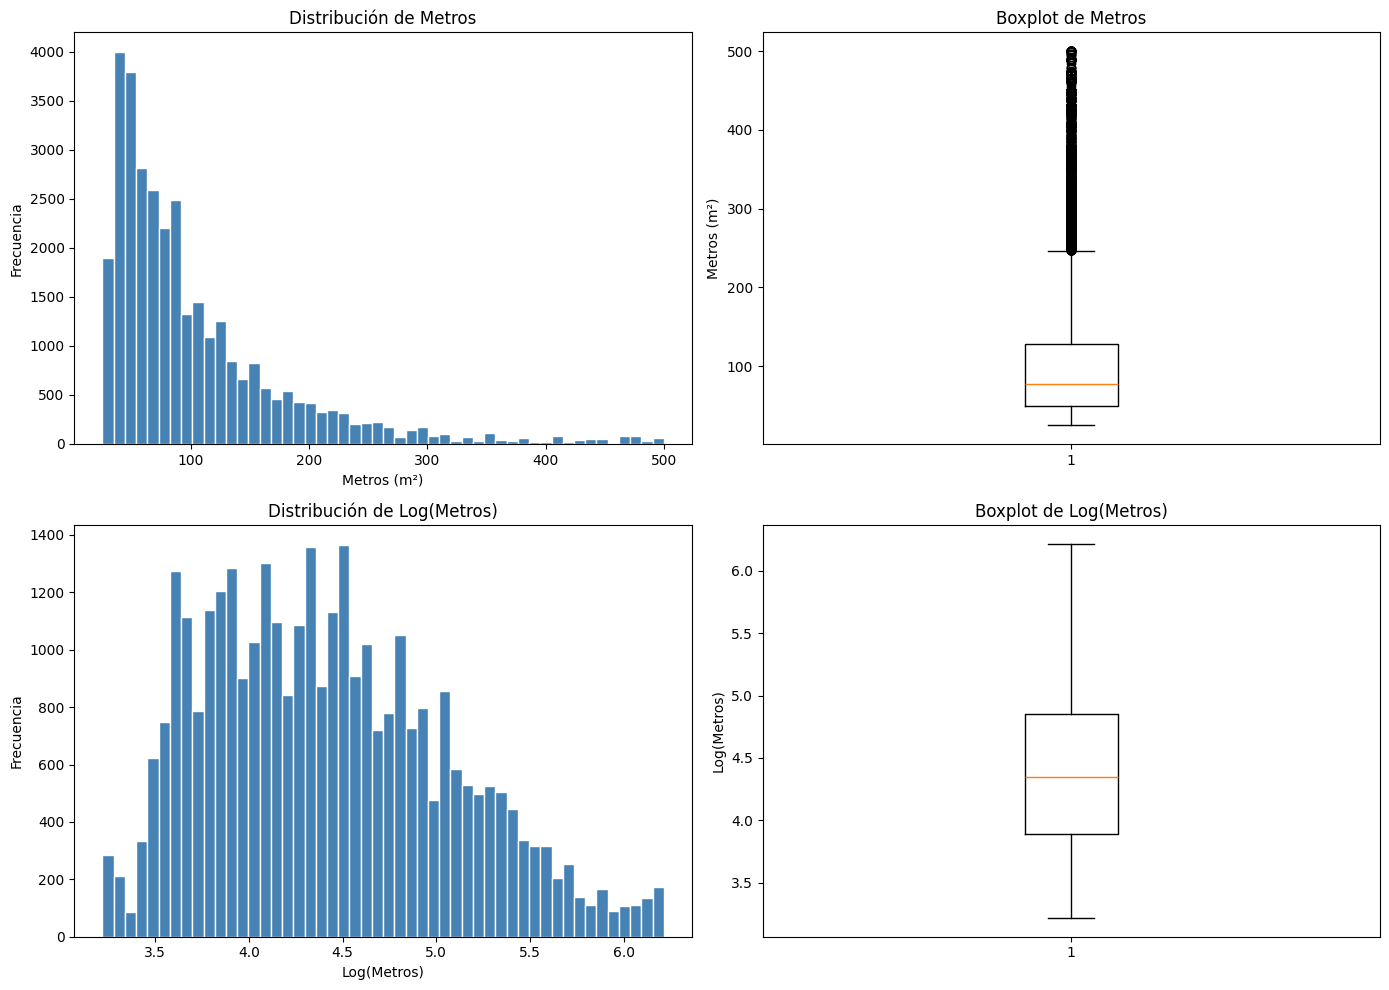

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma metros original
axes[0, 0].hist(df["metros"], bins=50, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Distribución de Metros")
axes[0, 0].set_xlabel("Metros (m²)")
axes[0, 0].set_ylabel("Frecuencia")

# Boxplot metros original
axes[0, 1].boxplot(df["metros"], vert=True)
axes[0, 1].set_title("Boxplot de Metros")
axes[0, 1].set_ylabel("Metros (m²)")

# Histograma log metros
log_metros = np.log(df["metros"])
axes[1, 0].hist(log_metros, bins=50, color="steelblue", edgecolor="white")
axes[1, 0].set_title("Distribución de Log(Metros)")
axes[1, 0].set_xlabel("Log(Metros)")
axes[1, 0].set_ylabel("Frecuencia")

# Boxplot log metros
axes[1, 1].boxplot(log_metros, vert=True)
axes[1, 1].set_title("Boxplot de Log(Metros)")
axes[1, 1].set_ylabel("Log(Metros)")

plt.tight_layout()
plt.show()

A diferencia del precio, aplicar logaritmo a metros no mejora significativamente la distribución, reflejando 
dos grupos naturales en CABA: departamentos chicos (40-80 m²) y casas/PH grandes (150-300 m²). Mantenemos metros en escala original.

#### 2.3 Expensas

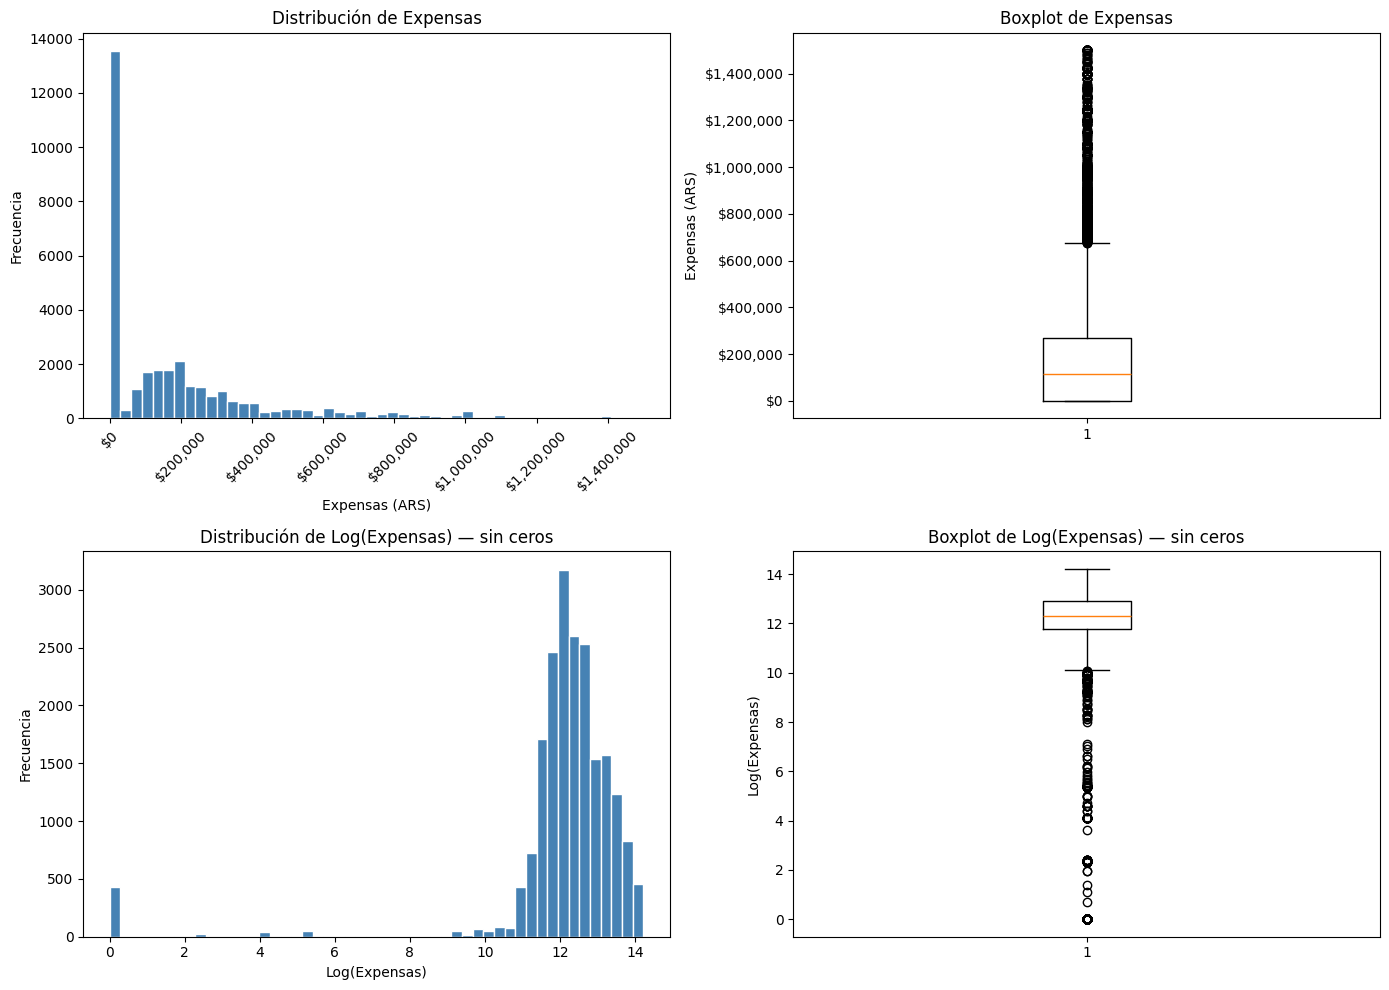

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma expensas original
axes[0, 0].hist(df["expensas"], bins=50, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Distribución de Expensas")
axes[0, 0].set_xlabel("Expensas (ARS)")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45)

# Boxplot expensas original
axes[0, 1].boxplot(df["expensas"], vert=True)
axes[0, 1].set_title("Boxplot de Expensas")
axes[0, 1].set_ylabel("Expensas (ARS)")
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

# Histograma log expensas (solo las que tienen expensas > 0)
log_expensas = np.log(df[df["expensas"] > 0]["expensas"])
axes[1, 0].hist(log_expensas, bins=50, color="steelblue", edgecolor="white")
axes[1, 0].set_title("Distribución de Log(Expensas) — sin ceros")
axes[1, 0].set_xlabel("Log(Expensas)")
axes[1, 0].set_ylabel("Frecuencia")

# Boxplot log expensas
axes[1, 1].boxplot(log_expensas, vert=True)
axes[1, 1].set_title("Boxplot de Log(Expensas) — sin ceros")
axes[1, 1].set_ylabel("Log(Expensas)")

plt.tight_layout()
plt.show()

La columna expensas presenta una distribución compleja debido a la mezcla 
de dos poblaciones: ~15k propiedades sin expensas (ceros) y ~18k con 
expensas positivas. Aplicando log a las positivas se obtiene una 
distribución normal, pero el problema de los ceros persiste.

Las opciones para manejarla en el modelo son:
- **Variable binaria**: `tiene_expensas` (0 o 1)
- **Log(expensas)**: solo para propiedades con expensas > 0
- **Ignorarla**